In [30]:
!pip install -q polars imbalanced-learn torch torchvision torchaudio

from pathlib import Path

import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    RocCurveDisplay
)
from imblearn.over_sampling import SMOTE

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cpu


In [31]:
import pandas as pd

# asumsi file .ipynb dan CSV ada di folder yang sama
train_pl = pd.read_csv("train_transaction.csv")
test_pl  = pd.read_csv("test_transaction.csv")

print("Train shape:", train_pl.shape)
print("Test shape :", test_pl.shape)
print("Fraud rate :", float(train_pl["isFraud"].mean()))

Train shape: (590540, 394)
Test shape : (506691, 393)
Fraud rate : 0.03499000914417313


In [32]:
df_train = train_pl

In [33]:
df_train.columns

Index(['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt',
       'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5',
       ...
       'V330', 'V331', 'V332', 'V333', 'V334', 'V335', 'V336', 'V337', 'V338',
       'V339'],
      dtype='object', length=394)

In [34]:
df_train

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.50,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.00,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.00,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.00,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.00,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
590535,3577535,0,15811047,49.00,W,6550,NaN,150.0,visa,226.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
590536,3577536,0,15811049,39.50,W,10444,225.0,150.0,mastercard,224.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
590537,3577537,0,15811079,30.95,W,12037,595.0,150.0,mastercard,224.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
590538,3577538,0,15811088,117.00,W,7826,481.0,150.0,mastercard,224.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [35]:
df_test = test_pl

In [36]:
df_test.columns

Index(['TransactionID', 'TransactionDT', 'TransactionAmt', 'ProductCD',
       'card1', 'card2', 'card3', 'card4', 'card5', 'card6',
       ...
       'V330', 'V331', 'V332', 'V333', 'V334', 'V335', 'V336', 'V337', 'V338',
       'V339'],
      dtype='object', length=393)

In [37]:
train_col = train_pl.columns
test_col = test_pl.columns

In [38]:
# check columns yang bertipe string
def check_dtype(df, col):
    obj_col = []
    for item in col:
        if df[item].dtype == "object":
            obj_col.append(item)

    return obj_col

In [39]:
test_check = check_dtype(df_test, test_col)

df_test[test_check].head()

,ProductCD,card4,card6,P_emaildomain,R_emaildomain,M1,M2,M3,M4,M5,M6,M7,M8,M9
0,W,visa,debit,gmail.com,NaN,T,T,F,NaN,NaN,F,T,T,T
1,W,visa,debit,aol.com,NaN,T,F,F,M0,NaN,F,NaN,NaN,NaN
2,W,visa,debit,hotmail.com,NaN,T,T,F,M0,F,F,F,F,F
3,W,visa,debit,gmail.com,NaN,T,T,T,NaN,NaN,T,NaN,NaN,NaN
4,W,mastercard,debit,gmail.com,NaN,T,T,T,NaN,NaN,F,F,T,T


In [40]:
train_check = check_dtype(df_train, train_col)

df_train[train_check].head()

,ProductCD,card4,card6,P_emaildomain,R_emaildomain,M1,M2,M3,M4,M5,M6,M7,M8,M9
0,W,discover,credit,NaN,NaN,T,T,T,M2,F,T,NaN,NaN,NaN
1,W,mastercard,credit,gmail.com,NaN,NaN,NaN,NaN,M0,T,T,NaN,NaN,NaN
2,W,visa,debit,outlook.com,NaN,T,T,T,M0,F,F,F,F,F
3,W,mastercard,debit,yahoo.com,NaN,NaN,NaN,NaN,M0,T,F,NaN,NaN,NaN
4,H,mastercard,credit,gmail.com,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [41]:
def value_counter(df, col):
    for item in col:
        print(item, df[item].value_counts())
        print()

In [42]:
value_counter(df_train, train_check)

ProductCD ProductCD
W    439670
C     68519
R     37699
H     33024
S     11628
Name: count, dtype: int64

card4 card4
visa                384767
mastercard          189217
american express      8328
discover              6651
Name: count, dtype: int64

card6 card6
debit              439938
credit             148986
debit or credit        30
charge card            15
Name: count, dtype: int64

P_emaildomain P_emaildomain
gmail.com           228355
yahoo.com           100934
hotmail.com          45250
anonymous.com        36998
aol.com              28289
comcast.net           7888
icloud.com            6267
outlook.com           5096
msn.com               4092
att.net               4033
live.com              3041
sbcglobal.net         2970
verizon.net           2705
ymail.com             2396
bellsouth.net         1909
yahoo.com.mx          1543
me.com                1522
cox.net               1393
optonline.net         1011
charter.net            816
live.com.mx            749
rocketma

In [43]:
value_counter(df_test, test_check)

ProductCD ProductCD
W    360987
C     69266
R     35647
H     29373
S     11418
Name: count, dtype: int64

card4 card4
visa                334882
mastercard          158169
american express      7681
discover              2873
Name: count, dtype: int64

card6 card6
debit          385021
credit         118662
charge card         1
Name: count, dtype: int64

P_emaildomain P_emaildomain
gmail.com           207448
yahoo.com            81850
hotmail.com          40399
anonymous.com        34064
aol.com              24048
comcast.net           6586
icloud.com            6049
outlook.com           4838
att.net               3614
msn.com               3388
sbcglobal.net         2797
live.com              2679
verizon.net           2306
ymail.com             1679
bellsouth.net         1528
yahoo.com.mx          1284
cox.net               1264
me.com                1191
optonline.net          926
live.com.mx            721
charter.net            627
mail.com               597
gmail              

In [44]:
from sklearn.preprocessing import LabelEncoder

def categorical_encoding(df):
    df = df.copy()

    encoders = {}

    # ----- Columns to encode -----
    freq_cols = ['P_emaildomain', 'R_emaildomain']
    label_cols = ['ProductCD', 'card4', 'card6']
    binary_cols = ['M1','M2','M3']
    m_cols = ['M4','M5','M6','M7','M8','M9']

    # 1. Frequency Encoding
    for col in freq_cols:
        freq = df[col].value_counts(dropna=False)
        df[col + '_FE'] = df[col].map(freq).fillna(0)

    # 2. Label Encoding
    for col in label_cols:
        le = LabelEncoder()
        df[col + '_LE'] = le.fit_transform(df[col].astype(str))
        encoders[col] = le

    # 3. Binary Encoding
    map_bin = {'T':1, 'F':0}
    map_m = {'T':1, 'F':0, 'M0':-1}

    for col in binary_cols:
        df[col + '_bin'] = df[col].map(map_bin).fillna(-1)

    for col in m_cols:
        df[col + '_bin'] = df[col].map(map_m).fillna(-1)

    # ----- Drop original columns -----
    cols_to_drop = freq_cols + label_cols + binary_cols + m_cols
    df.drop(columns=cols_to_drop, inplace=True)

    return df, encoders

In [45]:
train_clean, encoders = categorical_encoding(df_train)

In [46]:
train_clean

,TransactionID,isFraud,TransactionDT,TransactionAmt,card1,card2,card3,card5,addr1,addr2,...,card6_LE,M1_bin,M2_bin,M3_bin,M4_bin,M5_bin,M6_bin,M7_bin,M8_bin,M9_bin
0,2987000,0,86400,68.50,13926,NaN,150.0,142.0,315.0,87.0,...,1,1.0,1.0,1.0,-1.0,0.0,1.0,-1.0,-1.0,-1.0
1,2987001,0,86401,29.00,2755,404.0,150.0,102.0,325.0,87.0,...,1,-1.0,-1.0,-1.0,-1.0,1.0,1.0,-1.0,-1.0,-1.0
2,2987002,0,86469,59.00,4663,490.0,150.0,166.0,330.0,87.0,...,2,1.0,1.0,1.0,-1.0,0.0,0.0,0.0,0.0,0.0
3,2987003,0,86499,50.00,18132,567.0,150.0,117.0,476.0,87.0,...,2,-1.0,-1.0,-1.0,-1.0,1.0,0.0,-1.0,-1.0,-1.0
4,2987004,0,86506,50.00,4497,514.0,150.0,102.0,420.0,87.0,...,1,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
590535,3577535,0,15811047,49.00,6550,NaN,150.0,226.0,272.0,87.0,...,2,1.0,1.0,1.0,-1.0,1.0,0.0,0.0,0.0,1.0
590536,3577536,0,15811049,39.50,10444,225.0,150.0,224.0,204.0,87.0,...,2,1.0,0.0,0.0,-1.0,0.0,1.0,0.0,0.0,0.0
590537,3577537,0,15811079,30.95,12037,595.0,150.0,224.0,231.0,87.0,...,2,1.0,0.0,0.0,-1.0,-1.0,1.0,-1.0,-1.0,-1.0
590538,3577538,0,15811088,117.00,7826,481.0,150.0,224.0,387.0,87.0,...,2,1.0,1.0,1.0,-1.0,0.0,1.0,-1.0,-1.0,-1.0


In [47]:
test_clean, encoders = categorical_encoding(df_test)

In [48]:
test_clean

,TransactionID,TransactionDT,TransactionAmt,card1,card2,card3,card5,addr1,addr2,dist1,...,card6_LE,M1_bin,M2_bin,M3_bin,M4_bin,M5_bin,M6_bin,M7_bin,M8_bin,M9_bin
0,3663549,18403224,31.950,10409,111.0,150.0,226.0,170.0,87.0,1.0,...,2,1.0,1.0,0.0,-1.0,-1.0,0.0,1.0,1.0,1.0
1,3663550,18403263,49.000,4272,111.0,150.0,226.0,299.0,87.0,4.0,...,2,1.0,0.0,0.0,-1.0,-1.0,0.0,-1.0,-1.0,-1.0
2,3663551,18403310,171.000,4476,574.0,150.0,226.0,472.0,87.0,2635.0,...,2,1.0,1.0,0.0,-1.0,0.0,0.0,0.0,0.0,0.0
3,3663552,18403310,284.950,10989,360.0,150.0,166.0,205.0,87.0,17.0,...,2,1.0,1.0,1.0,-1.0,-1.0,1.0,-1.0,-1.0,-1.0
4,3663553,18403317,67.950,18018,452.0,150.0,117.0,264.0,87.0,6.0,...,2,1.0,1.0,1.0,-1.0,-1.0,0.0,0.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
506686,4170235,34214279,94.679,13832,375.0,185.0,224.0,284.0,60.0,NaN,...,2,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
506687,4170236,34214287,12.173,3154,408.0,185.0,224.0,NaN,NaN,NaN,...,2,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
506688,4170237,34214326,49.000,16661,490.0,150.0,226.0,327.0,87.0,NaN,...,2,1.0,1.0,1.0,-1.0,0.0,0.0,0.0,1.0,1.0
506689,4170238,34214337,202.000,16621,516.0,150.0,224.0,177.0,87.0,NaN,...,2,1.0,1.0,1.0,-1.0,0.0,0.0,0.0,0.0,0.0


In [49]:
TARGET = "isFraud"

# X & y dari train_clean
X = train_clean.drop(columns=[TARGET])
y = train_clean[TARGET]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [50]:
from sklearn.preprocessing import StandardScaler
import numpy as np

scaler = StandardScaler()

batch_size = 50000  # Bisa kamu kecilkan jika RAM lebih kecil

# FIT per batch
for i in range(0, len(X_train), batch_size):
    batch = X_train.iloc[i:i+batch_size]
    scaler.partial_fit(batch)


In [51]:
scaled_batches = []

for i in range(0, len(X_train), batch_size):
    batch = X_train.iloc[i:i+batch_size]
    scaled = scaler.transform(batch)
    scaled_batches.append(scaled)

X_train_scaled = np.vstack(scaled_batches)


In [52]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from imblearn.pipeline import make_pipeline as make_imb_pipeline
from imblearn.over_sampling import SMOTE

log_clf = make_imb_pipeline(
    SimpleImputer(strategy="median"),     # handle NaN di fitur
    StandardScaler(),                     # scale fitur biar mudah konvergen
    SMOTE(random_state=42),              # oversampling kelas minoritas
    LogisticRegression(
        solver="lbfgs",
        max_iter=100,                   # naikkan dari default 100
        n_jobs=-1,
        random_state=42
    )
)

log_clf.fit(X_train, y_train)
y_pred = log_clf.predict(X_val)


In [53]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import numpy as np

# imputasi (fit di train, transform ke train & val)
imputer = SimpleImputer(strategy="median")
X_train_imp = imputer.fit_transform(X_train)
X_val_imp   = imputer.transform(X_val)

# scaling (fit di train, transform ke train & val)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imp)
X_val_scaled   = scaler.transform(X_val_imp)

# SMOTE hanya di TRAIN
sm = SMOTE(random_state=42, n_jobs=-1)
X_train_res, y_train_res = sm.fit_resample(X_train_scaled, y_train)

print("Before SMOTE:", np.bincount(y_train))
print("After  SMOTE:", np.bincount(y_train_res))


C:\Users\Fakhriza Bondan\anaconda3\envs\py\lib\site-packages\imblearn\over_sampling\_smote\base.py:370: FutureWarning: The parameter `n_jobs` has been deprecated in 0.10 and will be removed in 0.12. You can pass an nearest neighbors estimator where `n_jobs` is already set instead.
  warnings.warn(


Before SMOTE: [455902  16530]
After  SMOTE: [455902 455902]


In [54]:
X_test_scaled = scaler.transform(test_clean)

C:\Users\Fakhriza Bondan\anaconda3\envs\py\lib\site-packages\sklearn\base.py:443: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


In [63]:
class SimpleMLP(nn.Module):
    def __init__(self, input_dim, hidden_sizes=(256, 128), dropout=0.2):
        super().__init__()
        h1, h2 = hidden_sizes
        self.net = nn.Sequential(
            nn.Linear(input_dim, h1),
            nn.BatchNorm1d(h1),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(h1, h2),
            nn.BatchNorm1d(h2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(h2, 1)
        )

    def forward(self, x):
        out = self.net(x)          # shape: [batch, 1]
        return out.squeeze(1)      # shape: [batch]


In [64]:
def train_and_eval(hidden_sizes=(256, 128), lr=5e-4, batch_size=2048, max_epochs=30,
                   patience=7, min_delta=1e-4, dropout=0.2, verbose=True):

    input_dim = X_train_t.shape[1]
    model = SimpleMLP(input_dim, hidden_sizes=hidden_sizes, dropout=dropout).to(device)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_ds, batch_size=4096, shuffle=False)

    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=0.0)

    best_val_loss = float("inf")
    epochs_no_improve = 0
    best_state_dict = None

    history = {"train_loss": [], "val_loss": [], "val_auc": []}
    val_probs_last, val_targets_last = None, None

    for epoch in range(1, max_epochs + 1):
        model.train()
        running_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device).unsqueeze(1)
            optimizer.zero_grad()
            preds = model(xb)
            loss = criterion(preds, yb)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * xb.size(0)

        train_loss = running_loss / len(train_loader.dataset)

        model.eval()
        val_running_loss = 0.0
        all_probs, all_targets = [], []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device).unsqueeze(1)
                preds = model(xb)
                loss = criterion(preds, yb)
                val_running_loss += loss.item() * xb.size(0)
                all_probs.append(preds.cpu().numpy())
                all_targets.append(yb.cpu().numpy())

        val_loss = val_running_loss / len(val_loader.dataset)
        all_probs = np.vstack(all_probs).ravel()
        all_targets = np.vstack(all_targets).ravel()
        val_auc = roc_auc_score(all_targets, all_probs)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_auc"].append(val_auc)
        val_probs_last, val_targets_last = all_probs, all_targets

        if verbose:
            print(
                f"Epoch {epoch:02d} | "
                f"Train Loss: {train_loss:.4f} | "
                f"Val Loss: {val_loss:.4f} | "
                f"Val AUC: {val_auc:.4f}"
            )

        improvement = best_val_loss - val_loss
        if improvement > min_delta:
            best_val_loss = val_loss
            epochs_no_improve = 0
            best_state_dict = model.state_dict()
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                if verbose:
                    print(f"Early stopping at epoch {epoch}")
                break

    if best_state_dict is not None:
        model.load_state_dict(best_state_dict)

    return model, history, val_probs_last, val_targets_last


In [65]:
def train_and_eval(
    hidden_sizes=(256, 128),
    lr=5e-4,
    batch_size=2048,
    max_epochs=30,
    patience=7,
    min_delta=1e-4,
    dropout=0.2,
    verbose=True
):
    # ---- siapkan tensor dari data global ----
    X_tr = torch.tensor(X_train_res, dtype=torch.float32)
    y_tr = torch.tensor(y_train_res.values, dtype=torch.float32)
    X_v  = torch.tensor(X_val_scaled, dtype=torch.float32)
    y_v  = torch.tensor(y_val.values, dtype=torch.float32)

    train_ds = TensorDataset(X_tr, y_tr)
    val_ds   = TensorDataset(X_v, y_v)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

    input_dim = X_tr.shape[1]
    model = SimpleMLP(input_dim, hidden_sizes=hidden_sizes, dropout=dropout).to(device)

    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {"train_loss": [], "val_loss": [], "val_auc": []}
    best_auc = 0.0
    best_state = None
    no_improve = 0

    for epoch in range(1, max_epochs + 1):
        # -------- TRAIN --------
        model.train()
        train_loss_sum = 0.0
        n_train = 0

        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            bs = xb.size(0)
            train_loss_sum += loss.item() * bs
            n_train += bs

        train_loss_epoch = train_loss_sum / n_train

        # -------- EVAL --------
        model.eval()
        val_loss_sum = 0.0
        n_val = 0
        all_logits = []
        all_targets = []

        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                logits = model(xb)
                loss = criterion(logits, yb)

                bs = xb.size(0)
                val_loss_sum += loss.item() * bs
                n_val += bs

                all_logits.append(logits.cpu())
                all_targets.append(yb.cpu())

        val_loss_epoch = val_loss_sum / n_val
        val_logits = torch.cat(all_logits)
        val_targets = torch.cat(all_targets)

        val_probs = torch.sigmoid(val_logits).numpy()
        val_true  = val_targets.numpy()
        val_auc_epoch = roc_auc_score(val_true, val_probs)

        history["train_loss"].append(train_loss_epoch)
        history["val_loss"].append(val_loss_epoch)
        history["val_auc"].append(val_auc_epoch)

        if verbose:
            print(
                f"Epoch {epoch:02d} | "
                f"train_loss={train_loss_epoch:.4f} | "
                f"val_loss={val_loss_epoch:.4f} | "
                f"val_auc={val_auc_epoch:.4f}"
            )

        # early stopping by AUC
        if val_auc_epoch > best_auc + min_delta:
            best_auc = val_auc_epoch
            best_state = model.state_dict()
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                if verbose:
                    print(f"Early stopping at epoch {epoch}, best AUC={best_auc:.4f}")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    # probabilitas val final
    model.eval()
    with torch.no_grad():
        logits_final = model(torch.tensor(X_val_scaled, dtype=torch.float32).to(device))
        y_val_prob = torch.sigmoid(logits_final).cpu().numpy()
    y_val_true = y_val.values

    return model, history, y_val_prob, y_val_true


Epoch 01 | train_loss=0.4031 | val_loss=0.3012 | val_auc=0.9012
Epoch 02 | train_loss=0.3127 | val_loss=0.2924 | val_auc=0.9089
Epoch 03 | train_loss=0.2794 | val_loss=0.2680 | val_auc=0.9143
Epoch 04 | train_loss=0.2602 | val_loss=0.2398 | val_auc=0.9121
Epoch 05 | train_loss=0.2447 | val_loss=0.2740 | val_auc=0.9198
Epoch 06 | train_loss=0.2334 | val_loss=0.2338 | val_auc=0.9206
Epoch 07 | train_loss=0.2231 | val_loss=0.1981 | val_auc=0.9194
Epoch 08 | train_loss=0.2148 | val_loss=0.2094 | val_auc=0.9217
Epoch 09 | train_loss=0.2091 | val_loss=0.2040 | val_auc=0.9202
Epoch 10 | train_loss=0.2015 | val_loss=0.1983 | val_auc=0.9200
Epoch 11 | train_loss=0.1967 | val_loss=0.2152 | val_auc=0.9219
Epoch 12 | train_loss=0.1917 | val_loss=0.1989 | val_auc=0.9231
Epoch 13 | train_loss=0.1858 | val_loss=0.1933 | val_auc=0.9228
Epoch 14 | train_loss=0.1814 | val_loss=0.1825 | val_auc=0.9208
Epoch 15 | train_loss=0.1784 | val_loss=0.1961 | val_auc=0.9245
Epoch 16 | train_loss=0.1728 | val_loss=

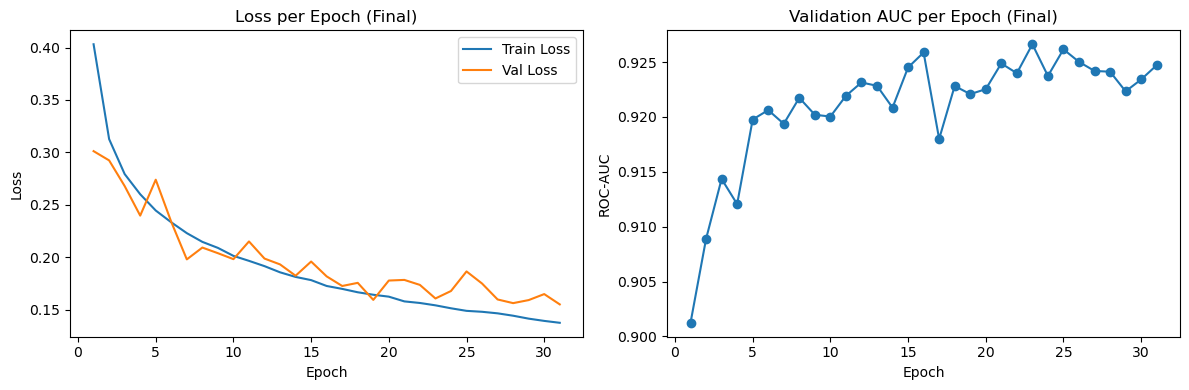

In [66]:
# jalankan training + evaluasi
final_model, final_hist, y_val_prob, y_val_true = train_and_eval(
    hidden_sizes=(256, 128),
    lr=5e-4,
    batch_size=2048,
    max_epochs=40,
    patience=8,
    dropout=0.2,
    verbose=True
)

# ekstrak history
train_loss_hist = final_hist["train_loss"]
val_loss_hist   = final_hist["val_loss"]
val_auc_hist    = final_hist["val_auc"]

epochs_ran = range(1, len(train_loss_hist) + 1)

plt.figure(figsize=(12, 4))

# plot loss
plt.subplot(1, 2, 1)
plt.plot(epochs_ran, train_loss_hist, label="Train Loss")
plt.plot(epochs_ran, val_loss_hist,   label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss per Epoch (Final)")
plt.legend()

# plot AUC
plt.subplot(1, 2, 2)
plt.plot(epochs_ran, val_auc_hist, marker="o")
plt.xlabel("Epoch")
plt.ylabel("ROC-AUC")
plt.title("Validation AUC per Epoch (Final)")

plt.tight_layout()
plt.show()



In [ ]:
from sklearn.metrics import classification_report

probs = y_val_prob  # array probabilitas kelas 1
true  = y_val_true  # array label 0/1

thresholds = [0.5, 0.4, 0.35, 0.3, 0.25, 0.2]
results_thr = []

for thr in thresholds:
    pred = (probs >= thr).astype(int)
    report = classification_report(true, pred, output_dict=True, digits=4)

    # kelas positif = label "1"
    f1_fraud       = report["1"]["f1-score"]
    recall_fraud   = report["1"]["recall"]
    precision_fraud= report["1"]["precision"]
    acc            = report["accuracy"]

    results_thr.append({
        "threshold": thr,
        "f1_fraud": f1_fraud,
        "recall_fraud": recall_fraud,
        "precision_fraud": precision_fraud,
        "accuracy": acc
    })

thr_df = pd.DataFrame(results_thr)
thr_df = thr_df.sort_values("f1_fraud", ascending=False)
thr_df


In [ ]:
thr_best = 0.3  # ganti sesuai hasil thr_df

y_val_pred_best = (probs >= thr_best).astype(int)

print(f"=== Classification report (validation) at threshold {thr_best} ===")
print(classification_report(true, y_val_pred_best, digits=4))

cm_best = confusion_matrix(true, y_val_pred_best)
plt.figure(figsize=(4,4))
sns.heatmap(cm_best, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"Confusion Matrix (Val) @ thr={thr_best}")
plt.show()

RocCurveDisplay.from_predictions(true, probs)
plt.title("ROC Curve (Validation)")
plt.show()


In [ ]:
# pastikan final_model sudah ter-train, dan ada X_test_scaled, test_pl, thr_best

final_model.eval()
with torch.no_grad():
    # pakai fitur TEST yang sudah di-impute + scale
    X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)
    test_logits_t = final_model(X_test_t)
    test_probs = torch.sigmoid(test_logits_t).cpu().numpy().ravel()

# pakai threshold terbaik dari tabel threshold-metric
test_pred_label = (test_probs >= thr_best).astype(int)

print(f"Threshold yang dipakai untuk test: {thr_best}\n")

print("Beberapa hasil prediksi test (label):")
print(test_pred_label[:20])

print("\nBeberapa hasil prediksi test (probabilitas isFraud):")
print(test_probs[:20])

# test_pl adalah DataFrame test yang sudah kamu load dari CSV
test_ids = test_pl["TransactionID"]

test_predictions_df = pd.DataFrame({
    "TransactionID": test_ids,
    "pred_isFraud_label": test_pred_label,
    "pred_isFraud_prob": test_probs,
})

print("\nPreview 20 baris pertama hasil prediksi test:")
test_predictions_df.head(20)
